# Full quantum simulation of the symmetric Mach-Zehnder -- RID 75603

This is the simulation companion to `declarative_symmetric_mz_rid75603.py`
(which only decodes the dump). Here we build the `lmt_sim` pulse sequence from
the genuine ARTIQ RID 75603 pulse record
(`DeclarativeLMTGlobalSymmetricMachZehnder`, icl_experiments ref `27b19683`),
reinsert the clearouts the recorder cannot store, and run the **full quantum
propagation** (`run_pulse_sequence_in_lab_frame`).

Three things the pulse record cannot capture have to be reapplied -- same shape
as the RID 74397 shaped-double-launch analysis:

1. **Probe (AC-Stark) shift and initial velocity.** Backed out of the dump with
   `calibrate_probe_shift_and_velocity_from_dump` so every recorded pulse lands
   on the recoil ladder. This is a *self-consistent fit*, not a measurement
   (the function emits a loud warning saying so); we accept it here purely to
   anchor the exported sequence onto the intended rungs.
2. **Clearouts.** The lab fires 461 nm ground-state clearout pulses that the
   pulse record does not store. The symmetric-MZ builder
   (`symmetric_mach_zehnder_sequence` in icl_experiments) places exactly two:
   one after the velocity-selection slice and one after the launch ladder.
3. **The second pulse is a shaped (Jesse) pulse.** The first launch pulse
   (`|e,+1> -> |g,+2>` on the down beam, fired right after the slice + clearout)
   is a phase-shaped `JessePulseLMT`, not a plain square pulse. The recorder
   stores it as a square pulse at the carrier. **Full quantum propagation of a
   shaped pulse is not implemented** (see the guard in
   `iter_pulse_sequence_in_borde_representation` and docs/roadmap.md), so -- as
   asked -- we *identify* it but feed it to the simulator as the ordinary
   square pulse the recorder stored. It happens to sit on the correct rung
   (-3), so a square pi pulse drives the same `|e,+1> -> |g,+2>` transition; we
   are only discarding the shaping (its velocity/Rabi robustness), not
   mistargeting the pulse.

Schedule shape: **30 clock pulses = 1 velocity-selection slice + 10 launch
pulses + 19 interferometer pulses** at `n_launch=10`, `n_recoils=2`.

In [1]:
import sys
import dataclasses
import warnings

sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt

import lmt_sim.lmt_simulation as sim
import lmt_sim.lmt_sequence as seq

REC = sim.RECOIL_FREQUENCY_HZ

In [2]:
# Genuine new-format pulse dump from ARTIQ RID 75603
# (DeclarativeLMTGlobalSymmetricMachZehnder): float64 SI pulse_record_flat as
# emitted by PulseDMARecording in icl_experiments.
pulse_record_flat = np.array(
    [
        30.0,
        1.0,
        0.0,
        1.0,
        0.0,
        1.0,
        0.0,
        1.0,
        0.0,
        1.0,
        0.0,
        1.0,
        0.0,
        1.0,
        1.0,
        0.0,
        0.0,
        0.0,
        0.0,
        1.0,
        1.0,
        0.0,
        1.0,
        1.0,
        0.0,
        0.0,
        0.0,
        0.0,
        1.0,
        1.0,
        0.0,
        0.0011392000000000002,
        0.0019425760000000001,
        0.0020322960000000003,
        0.002109016,
        0.002198736,
        0.0022754560000000004,
        0.002365176,
        0.0024418960000000003,
        0.002531616,
        0.002608336,
        0.0026980560000000003,
        0.002974792,
        0.003064512,
        0.0031412320000000003,
        0.003217952,
        0.003307672,
        0.003447392,
        0.0035371120000000002,
        0.0036268320000000004,
        0.003703552,
        0.0037802720000000003,
        0.003869992,
        0.003946712000000001,
        0.004023432,
        0.004113152,
        0.004252872,
        0.004342592,
        0.004432312,
        0.0045090320000000005,
        0.004585752,
        0.00038,
        6.8e-05,
        5.5e-05,
        6.8e-05,
        5.5e-05,
        6.8e-05,
        5.5e-05,
        6.8e-05,
        5.5e-05,
        6.8e-05,
        5.5e-05,
        6.8e-05,
        5.5e-05,
        5.5e-05,
        6.8e-05,
        6.8e-05,
        6.8e-05,
        6.8e-05,
        5.5e-05,
        5.5e-05,
        6.8e-05,
        5.5e-05,
        5.5e-05,
        6.8e-05,
        6.8e-05,
        6.8e-05,
        6.8e-05,
        5.5e-05,
        5.5e-05,
        6.8e-05,
        79993964.06464231,
        80006330.30636367,
        79985391.81854664,
        80022797.46822198,
        79968924.6566883,
        80039264.63008031,
        79952457.49482998,
        80055731.79193862,
        79935990.33297166,
        80072198.95379695,
        79919523.17111334,
        80085857.75577933,
        79905864.36913097,
        79925745.66179599,
        80101247.71696529,
        80062379.80351797,
        80098026.22423503,
        80059158.31078771,
        79913759.72212993,
        79933641.01479495,
        80074548.27197365,
        79917173.85293663,
        79937055.14560165,
        80089938.23315963,
        80051070.31971231,
        80086716.74042937,
        80047848.82698204,
        79925069.20593558,
        79944950.4986006,
        80063238.788168,
        200000000.0,
        200000000.0,
        200000000.0,
        200000000.0,
        200000000.0,
        200000000.0,
        200000000.0,
        200000000.0,
        200000000.0,
        200000000.0,
        200000000.0,
        200000000.0,
        200000000.0,
        200000000.0,
        200000000.0,
        200000000.0,
        200000000.0,
        200000000.0,
        200000000.0,
        200000000.0,
        200000000.0,
        200000000.0,
        200000000.0,
        200000000.0,
        200000000.0,
        200000000.0,
        200000000.0,
        200000000.0,
        200000000.0,
        200000000.0,
        99436000.0,
        99436000.0,
        99436000.0,
        99436000.0,
        99436000.0,
        99436000.0,
        99436000.0,
        99436000.0,
        99436000.0,
        99436000.0,
        99436000.0,
        99436000.0,
        99436000.0,
        99436000.0,
        99436000.0,
        99436000.0,
        99436000.0,
        99436000.0,
        99436000.0,
        99436000.0,
        99436000.0,
        99436000.0,
        99436000.0,
        99436000.0,
        99436000.0,
        99436000.0,
        99436000.0,
        99436000.0,
        99436000.0,
        99436000.0,
        0.012,
        2.6,
        2.6,
        2.6,
        2.6,
        2.6,
        2.6,
        2.6,
        2.6,
        2.6,
        2.6,
        2.6,
        2.6,
        2.6,
        2.6,
        2.6,
        2.6,
        2.6,
        2.6,
        2.6,
        2.6,
        2.6,
        2.6,
        2.6,
        2.6,
        2.6,
        2.6,
        2.6,
        2.6,
        2.6,
    ]
)
pulse_record_offsets = np.array([0], dtype=np.int64)

dump = seq.decode_pulse_record_flat(pulse_record_flat, pulse_record_offsets)[0]
n_pulses = len(dump.is_up)
assert n_pulses == 30, n_pulses

## Anchor the recoil ladder: probe shift and initial velocity

`calibrate_probe_shift_and_velocity_from_dump` reverse-engineers the AC-Stark
coefficient and the residual launch velocity by *assuming* every pulse was
meant to sit on the integer recoil ladder. It is a self-fulfilling calibration,
not a measurement (hence the loud `UserWarning`); we use it only to put the
exported sequence onto the rungs the experiment intended. With these values the
recorded detunings land on odd recoil rungs to a few hundredths of a recoil on
both beams.

In [3]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)
    PROBE_SHIFT_ALPHA, INITIAL_VELOCITY_Z = (
        seq.calibrate_probe_shift_and_velocity_from_dump(**dataclasses.asdict(dump))
    )

print(f"calibrated probe-shift alpha = {PROBE_SHIFT_ALPHA:.4g} 1/Hz")
print(f"inferred initial velocity    = {INITIAL_VELOCITY_Z * 1e3:+.3f} mm/s")

# The build folds the free-fall Doppler shift out into the recorded detunings
# (it works in the freely-falling frame and assumes zero starting velocity), so
# INITIAL_VELOCITY_Z is consumed HERE to compute that compensation; the quantum
# run below is then done at vz = 0.
_timestamps, base_sequence = seq.build_sequence_from_lab_pulse_dump(
    **dataclasses.asdict(dump),
    probe_induced_alpha_up=PROBE_SHIFT_ALPHA,
    probe_induced_alpha_down=PROBE_SHIFT_ALPHA,
    initial_velocity_z=INITIAL_VELOCITY_Z,
)
base_pulses = [e for e in base_sequence if isinstance(e, seq.Pulse)]
assert len(base_pulses) == n_pulses


def effective_rung(pulse):
    return (
        sim._effective_detuning_hz(
            pulse.detuning_hz,
            pulse.probe_shift_coefficient,
            pulse.effective_stark_rabi_frequency,
        )
        / REC
    )


rungs = np.array([effective_rung(p) for p in base_pulses])
residuals = rungs - np.array([2 * round((r - 1) / 2) + 1 for r in rungs])
print(
    f"odd-rung residuals: rms {np.sqrt(np.mean(residuals**2)):.3f}, "
    f"max |.| {np.max(np.abs(residuals)):.3f} recoils"
)
assert np.max(np.abs(residuals)) < 0.1

calibrated probe-shift alpha = 1.081e-07 1/Hz
inferred initial velocity    = +13.956 mm/s
odd-rung residuals: rms 0.018, max |.| 0.028 recoils


## Identify the shaped second pulse (the Jesse pulse)

Pulse 0 is the 380 us velocity-selection slice (`|g,0> -> |e,+1>`, up beam,
rung +1). Pulse 1 is the first launch pulse: the down beam driving
`|e,+1> -> |g,+2>` on rung -3 -- fired immediately after the slice + clearout.
In the live experiment this is a phase-shaped **`JessePulseLMT`**, engineered
to transfer the velocity-selected slice robustly; the recorder stores it as the
plain square pulse below.

As asked, we keep it as that square pulse for the full quantum run: full
propagation of a shaped pulse is not implemented (the arm-restricted /
simultaneous stand-in used for RID 74397 is rejected by
`iter_pulse_sequence_in_borde_representation`). Because the recorded square
pulse already sits on the correct rung (-3), it drives the same transition --
we only drop the shaping, not the target.

In [4]:
jesse = base_pulses[1]
assert jesse.k == -1 and abs(effective_rung(jesse) - (-3)) < 0.1, effective_rung(jesse)
print(
    f"second pulse (Jesse, modelled as square): k={jesse.k:+d}, "
    f"rung {effective_rung(jesse):+.2f}, duration {jesse.duration * 1e6:.0f} us, "
    f"Rabi {jesse.rabi_frequency:.0f} Hz"
)
# Relabel so it is visible in the sequence as the Jesse pulse; it stays an
# ordinary square Pulse (no restrict_to_m_ground / simultaneous_with_previous),
# so the Bordé propagation treats it exactly as a normal pulse.
base_sequence = [
    dataclasses.replace(e, label="jesse_as_square") if e is jesse else e
    for e in base_sequence
]

second pulse (Jesse, modelled as square): k=-1, rung -3.00, duration 68 us, Rabi 7353 Hz


## Reinsert the clearouts

`symmetric_mach_zehnder_sequence` (icl_experiments) fires two 461 nm
ground-state clearouts that the pulse record does not store:

* **after the slice** (`post_slice`): throws away the unselected ground cloud,
  leaving the velocity-selected slice in `|e,+1>`.
* **after the launch ladder** (`post_launch`): only present because the launch
  count is even (`n_launch=10`), so the launched packet ends excited and the
  residual ground population can be cleared.

Both are inserted with zero duration (the recorded inter-pulse gaps already
appear as freefall, so the clearouts must not add time), after pulse indices 0
and 10 in the dump numbering.

In [5]:
CLEAROUT_AFTER = {0: "post_slice", 10: "post_launch"}

sequence = []
pulse_index = -1
for event in base_sequence:
    sequence.append(event)
    if isinstance(event, seq.Pulse):
        pulse_index += 1
        if pulse_index in CLEAROUT_AFTER:
            sequence.append(
                seq.Clearout(duration=0.0, label=CLEAROUT_AFTER[pulse_index])
            )

n_clearouts = sum(isinstance(e, seq.Clearout) for e in sequence)
n_freefall = sum(isinstance(e, seq.Freefall) for e in sequence)
print(
    f"sequence: {len(sequence)} events = {n_pulses} pulses + {n_clearouts} clearouts "
    f"+ {n_freefall} freefall"
)
assert n_clearouts == 2

sequence: 62 events = 30 pulses + 2 clearouts + 30 freefall


## Run the full quantum simulation

A single Sr-87 atom is released in `|g,0>` and propagated through the whole
sequence with `run_pulse_sequence_in_lab_frame`. Every pulse doubles the row
count; off-resonant branches are pruned by `discard_threshold`. We use
`1e-6` -- the surviving populations are unchanged versus the `1e-9` default
(verified: the dominant output branch agrees to 4 decimal places) while keeping
the row count ~1e3 instead of ~1e4.

The clearout is a projective measurement, so the run is stochastic; for an atom
on the slice resonance it is in practice deterministic (the slice transfers it
fully to `|e,+1>`, so neither clearout ever fires). We confirm that with a
short Monte-Carlo over the clearout RNG, then read the populations off a single
representative run.

In [6]:
DISCARD_THRESHOLD = 1e-6


def run_once(rng):
    state = sim.make_atom_states(c0=1, c1=0, initial_velocity_z=0.0)
    result = seq.run_pulse_sequence_in_lab_frame(
        state,
        sequence,
        initial_velocity_z=0.0,
        discard_threshold=DISCARD_THRESHOLD,
        rng=rng,
    )
    return None if result is None else result[0]


# Short MC over the clearout randomness: confirm the on-resonance atom survives.
from tests.test_states_vector import run_clearout_trials  # noqa: E402

p_ground, p_excited, p_discarded = run_clearout_trials(
    run_once, n_trials=40, rng=np.random.default_rng(0)
)
print(
    f"over 40 clearout trials: P_ground={p_ground:.3f} "
    f"P_excited={p_excited:.3f} P_discarded={p_discarded:.3f}"
)
assert p_discarded < 0.05  # the slice + clearout keeps the selected atom

over 40 clearout trials: P_ground=0.907 P_excited=0.096 P_discarded=0.000


## Final momentum-branch populations

The interferometer recombines back to a dominant single momentum class. The
scattered satellite branches are the imperfections we knowingly kept in: the
square stand-in for the Jesse pulse (no velocity robustness) and the
few-hundredths-of-a-recoil off-resonance of the plain pi pulses.

In [7]:
final = run_once(np.random.default_rng(1))
assert final is not None

probs = np.abs(final.amplitudes) ** 2
# Collapse rows that share (m, internal state) into one population each.
branches = {}
for m, is_ground, p in zip(final.m_values, final.internal_is_ground, probs):
    key = (int(m), bool(is_ground))
    branches[key] = branches.get(key, 0.0) + float(p)

top = sorted(branches.items(), key=lambda kv: kv[1], reverse=True)
print(f"total surviving population = {sum(branches.values()):.4f}")
print("dominant branches:")
for (m, is_ground), p in top[:6]:
    if p > 1e-3:
        print(f"  m={m:+d}  {'ground' if is_ground else 'excited'}  population {p:.4f}")

dominant = top[0]
print(
    f"\nrecombined output: m={dominant[0][0]:+d} "
    f"{'ground' if dominant[0][1] else 'excited'}, population {dominant[1]:.3f}"
)

total surviving population = 1.0000
dominant branches:
  m=+12  ground  population 0.7511
  m=+10  ground  population 0.0726
  m=+9  excited  population 0.0552
  m=+13  excited  population 0.0521
  m=+14  ground  population 0.0497
  m=+11  excited  population 0.0086

recombined output: m=+12 ground, population 0.751


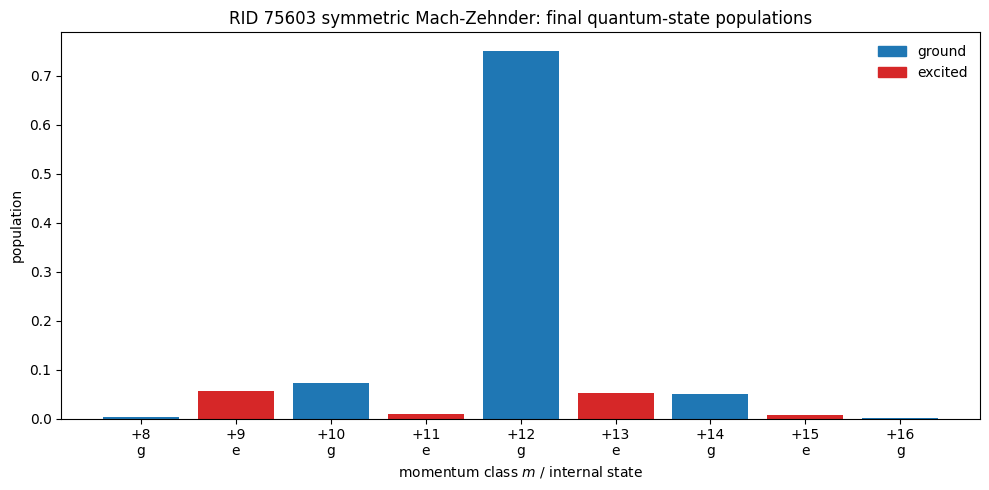

In [8]:
labelled = [(m, g, p) for (m, g), p in branches.items() if p > 1e-3]
labelled.sort(key=lambda x: x[0])
xs = np.arange(len(labelled))

fig, ax = plt.subplots(figsize=(10, 5))
colours = ["tab:blue" if g else "tab:red" for _, g, _ in labelled]
ax.bar(xs, [p for *_, p in labelled], color=colours, width=0.8)
ax.set_xticks(xs)
ax.set_xticklabels([f"{m:+d}\n{'g' if g else 'e'}" for m, g, _ in labelled])
ax.set_xlabel("momentum class $m$ / internal state")
ax.set_ylabel("population")
ax.set_title("RID 75603 symmetric Mach-Zehnder: final quantum-state populations")
from matplotlib.patches import Patch  # noqa: E402

ax.legend(
    handles=[
        Patch(color="tab:blue", label="ground"),
        Patch(color="tab:red", label="excited"),
    ],
    frameon=False,
)
fig.tight_layout()
plt.show()